## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')
# Show all columns
pd.set_option("display.max_columns", None)

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')


## Load the Dataset

In [2]:
df = pd.read_csv('D:\Customer-Churn-Analytics\Data\cleaned_superstore.csv')
df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,profit_margin,shipping_days,order_year,order_month,order_quarter,order_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,220.0464,16.0,3,2016,11,4,8
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,512.3580,30.0,3,2016,11,4,8


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub_category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

## Convert Datatype

In [4]:
columns = ['order_date', 'ship_date']

for col in columns:
    df[col] = pd.to_datetime(df[col]) 
    

### Recency -- how recent customer made a purchase 

In [5]:
# Group customers by their latest order date
recency = df.groupby(['customer_id', 'customer_name'])['order_date'].max().reset_index()

# Create a reference date (1 day after the latest order date)
reference_date = df["order_date"].max() + pd.Timedelta(days=1)
a
# Calculate the number of days since each customer's last purchase
recency['recency'] = (reference_date - recency['order_date']).dt.days


NameError: name 'a' is not defined

### Frequency -- How often a customer makes a purchase

In [ ]:
# Count the number of unique orders placed by each customer
frequency = df.groupby(['customer_id','customer_name'])['order_id'].nunique().reset_index()
# Rename the order_id column to frequency
frequency.rename(columns={'order_id':'frequency'},inplace=True)

### Monetary -- How much money a customer spends

In [ ]:
# Calculate the total sales generated by each customer
monetary = df.groupby(['customer_id','customer_name'])['sales'].sum().reset_index()

# Rename the sales column to monetary
monetary.rename(columns={'sales':'monetary'},inplace=True)

## Merging all the grouped data 

In [ ]:
# Merge recency, frequency, and monetary into a single RFM DataFrame
rfm = (
    recency
    .merge(frequency, on=['customer_id', 'customer_name'])
    .merge(monetary, on=['customer_id', 'customer_name'])
)
rfm = recency\
    .merge(frequency, on=['customer_id','customer_name'])\
    .merge(monetary, on=['customer_id','customer_name'])
rfm.columns

Index(['customer_id', 'customer_name', 'order_date', 'recency', 'frequency',
       'monetary'],
      dtype='str')

In [ ]:
# Keep only the required columns for RFM analysis
rfm = rfm[['customer_id',
    'customer_name',
    'recency',
    'frequency',
    'monetary']]

In [ ]:
rfm.head()

,customer_id,customer_name,recency,frequency,monetary
0,AA-10315,Alex Avila,185,5,5563.560
1,AA-10375,Allen Armold,20,9,1056.390
2,AA-10480,Andrew Allen,260,4,1790.512
3,AA-10645,Anna Andreadi,56,6,5086.935
4,AB-10015,Aaron Bergman,416,3,886.156


In [ ]:
rfm.to_csv('D:\Customer-Churn-Analytics\Data\customer_rfm.csv', index=False)

# Calculate RFM Scores

In [ ]:
# Customers with lower recency are more valuable
# we reverse the scores so lower recency gets a higher score

rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1])
rfm.head(3)

,customer_id,customer_name,recency,frequency,monetary,r_score
0,AA-10315,Alex Avila,185,5,5563.560,2
1,AA-10375,Allen Armold,20,9,1056.390,5
2,AA-10480,Andrew Allen,260,4,1790.512,1


In [ ]:
# Customers with more orders receive higher scores
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm.head(3)

,customer_id,customer_name,recency,frequency,monetary,r_score,f_score
0,AA-10315,Alex Avila,185,5,5563.560,2,2
1,AA-10375,Allen Armold,20,9,1056.390,5,5
2,AA-10480,Andrew Allen,260,4,1790.512,1,1


In [ ]:
# Customers who spend more receive higher scores
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])
rfm.head(3)

,customer_id,customer_name,recency,frequency,monetary,r_score,f_score,m_score
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3


In [ ]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   customer_id    793 non-null    str     
 1   customer_name  793 non-null    str     
 2   recency        793 non-null    int64   
 3   frequency      793 non-null    int64   
 4   monetary       793 non-null    float64 
 5   r_score        793 non-null    category
 6   f_score        793 non-null    category
 7   m_score        793 non-null    category
dtypes: category(3), float64(1), int64(2), str(2)
memory usage: 50.0 KB


In [ ]:
# Convert categorical scores into integer values

columns = ['r_score', 'f_score', 'm_score']

for col in columns:
    rfm[col] = rfm[col].astype(int)
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    793 non-null    str    
 1   customer_name  793 non-null    str    
 2   recency        793 non-null    int64  
 3   frequency      793 non-null    int64  
 4   monetary       793 non-null    float64
 5   r_score        793 non-null    int64  
 6   f_score        793 non-null    int64  
 7   m_score        793 non-null    int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 66.1 KB


In [ ]:
# Calculate the overall RFM score by summing individual scores

rfm['rfm_score'] = (rfm['r_score'] + rfm['f_score'] + rfm['m_score'])
rfm.head(3)

,customer_id,customer_name,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,9
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2,12
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,5


## Customer Segmentation

### Creating a column for categorizing customers into business segments based on RFM score

In [ ]:
def customer_segment(score):
    if score >= 13:
        return 'Champions'
    if score >= 10:
        return 'Loyal Customers'
    if score >= 7:
        return 'Potential Loyalists'
    if score >= 4:
        return 'At Risk'
    else:
        return 'Lost Customers'

In [ ]:
rfm['customer_segment'] = rfm['rfm_score'].apply(customer_segment)

In [ ]:
rfm['customer_segment'].value_counts()

customer_segment
Loyal Customers        254
Potential Loyalists    219
At Risk                157
Champions              124
Lost Customers          39
Name: count, dtype: int64

# Churn Mertics

In [ ]:
# Customers who havent purchased for more than 90 days
# are considered churned

rfm['churn'] = np.where(
    rfm['recency'] > 90,
    1,
    0
)

In [ ]:
rfm['churn'].value_counts()

churn
0    434
1    359
Name: count, dtype: int64

In [ ]:
# Save the processed customer dataset
rfm.to_csv("D:\Customer-Churn-Analytics\Data/customer_rfm.csv", index=False)

## EDA on RFM 

In [ ]:
rfm.columns

Index(['customer_id', 'customer_name', 'recency', 'frequency', 'monetary',
       'r_score', 'f_score', 'm_score', 'rfm_score', 'customer_segment',
       'churn'],
      dtype='str')

### Distribution of Recency


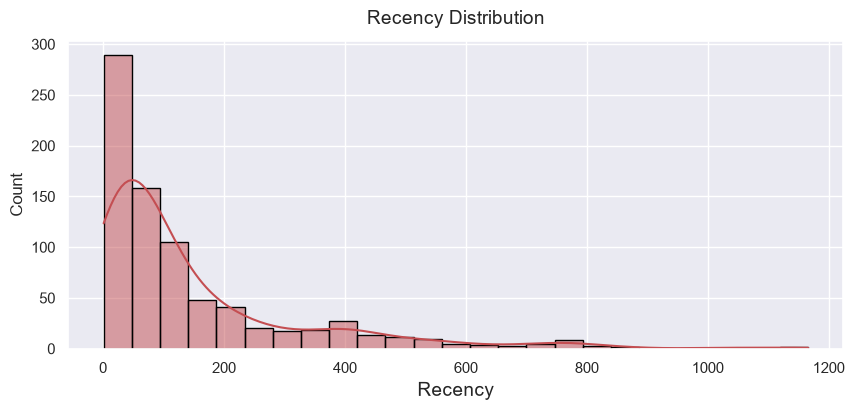

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot( x=rfm['recency'], bins=25, kde=True, edgecolor='black', color='r')
# adding titles
plt.title('Recency Distribution', fontsize=14, pad=12)
plt.xlabel('Recency',fontsize=14)
plt.show()

### Distribution of Frequency


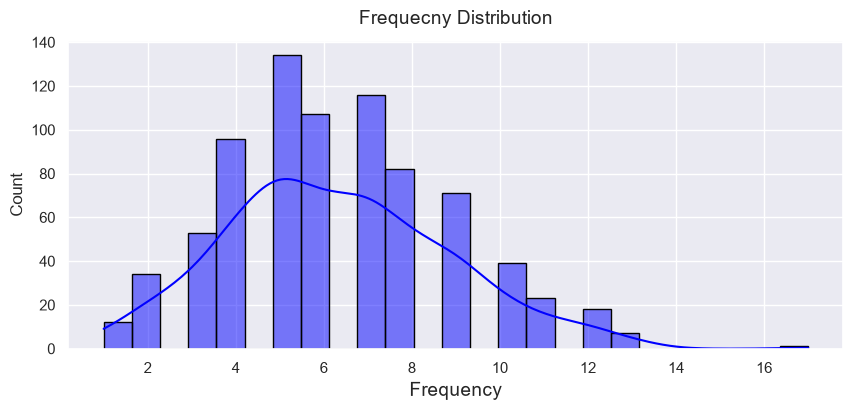

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot( x=rfm['frequency'], kde=True, edgecolor='black', color='blue')
# adding titles
plt.title('Frequecny Distribution', fontsize=14, pad=12)
plt.xlabel('Frequency',fontsize=14)
plt.show()

### Distribution of Monetary


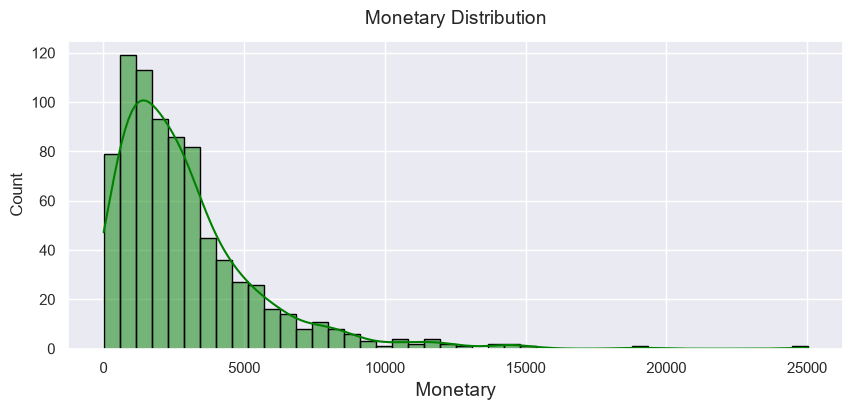

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot( x=rfm['monetary'], kde=True, edgecolor='black', color='green')
# adding titles
plt.title('Monetary Distribution',fontsize=14, pad=12)
plt.xlabel('Monetary',fontsize=14)
plt.show()

### customers by customer_segment

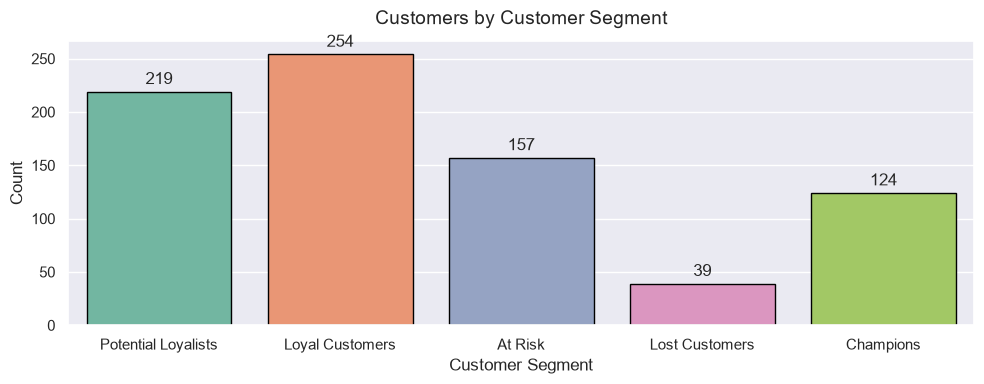

In [ ]:
plt.figure(figsize=(10, 4))

# Explicitly setting hue prevents Seaborn's palette deprecation warning
ax = sns.countplot(
    x=rfm['customer_segment'],
    palette='Set2',
    edgecolor='black',
)

# Customizing titles and labels
plt.title('Customers by Customer Segment', fontsize=14, pad=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Label each bar 
for container in ax.containers:
  ax.bar_label(container, padding=3)


plt.tight_layout()
plt.show()

### churn vs non-churn

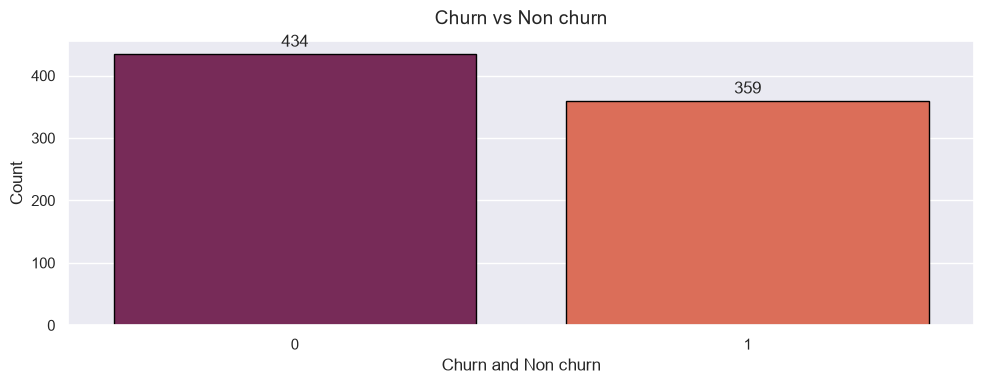

In [ ]:
plt.figure(figsize=(10, 4))

# Explicitly setting hue prevents Seaborn's palette deprecation warning
ax = sns.countplot(
    x=rfm['churn'],
    palette='rocket',
    edgecolor='black',
)

# Customizing titles and labels
plt.title('Churn vs Non churn', fontsize=14, pad=12)
plt.xlabel('Churn and Non churn', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Label each bar 
for container in ax.containers:
  ax.bar_label(container, padding=3)


plt.tight_layout()
plt.show()

### Monetary by customer_segment

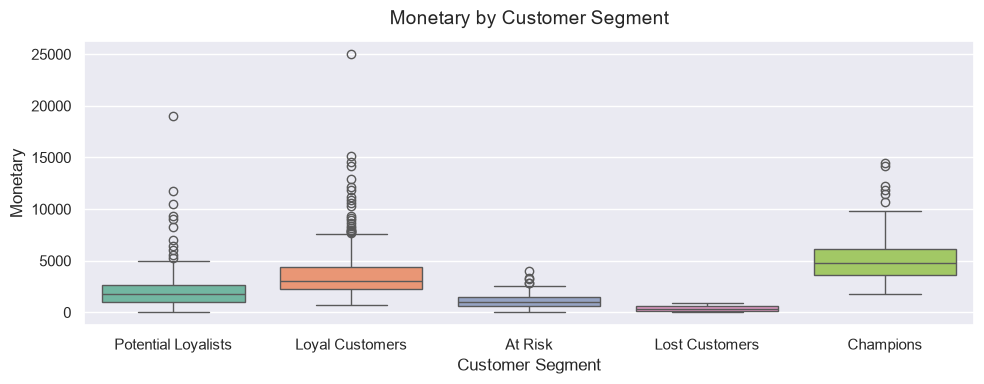

In [ ]:
plt.figure(figsize=(10, 4))

# Explicitly setting hue prevents Seaborn's palette deprecation warning
sns.boxplot(
    x=rfm['customer_segment'],
    y=rfm['monetary'],
    palette='Set2',
)

# Customizing titles and labels
plt.title('Monetary by Customer Segment', fontsize=14, pad=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Monetary', fontsize=12)


plt.tight_layout()
plt.show()

### Recency by churn

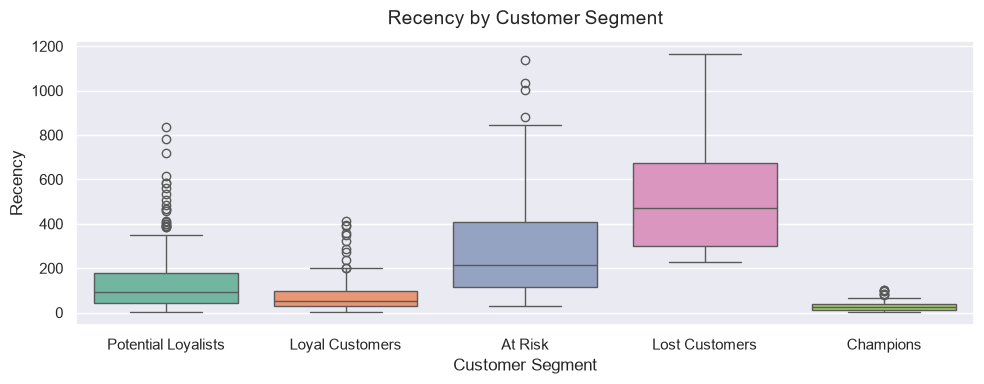

In [ ]:
plt.figure(figsize=(10, 4))

# Explicitly setting hue prevents Seaborn's palette deprecation warning
sns.boxplot(
    x=rfm['customer_segment'],
    y=rfm['recency'],
    palette='Set2',
)

# Customizing titles and labels
plt.title('Recency by Customer Segment', fontsize=14, pad=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Recency', fontsize=12)


plt.tight_layout()
plt.show()

### Correlation Heatmap


<Axes: >

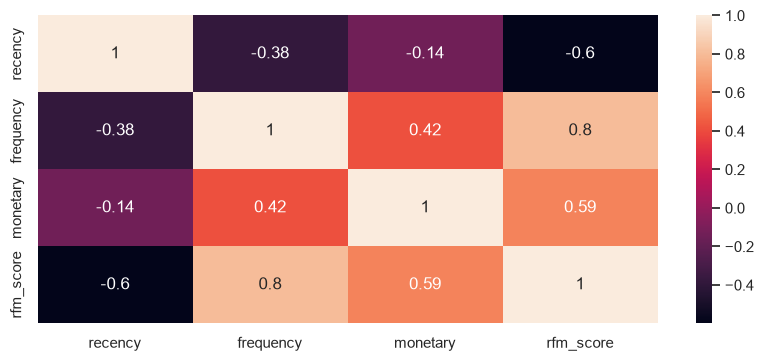

In [ ]:
plt.figure(figsize=(10, 4))

rfm_corr = rfm[['recency', 'frequency', 'monetary', 'rfm_score']].corr()

sns.heatmap(rfm_corr, annot=True, )